## Week8 - An Introduction to Reinforcement Learning and Deep Q-Learning

This notebook serves as part of the **Computer Intelligence and its Applications in Mechatronics** course at **Amirkabir University of Technology**. 
In this notebook, we will explore the basics of reinforcement learning (RL) and implement a simple deep Q-learning algorithm using Tensorflow and Keras. We will first introduce the OpenAI Gym, a toolkit for developing and comparing reinforcement learning algorithms. Then, we will implement a deep Q-learning agent to solve the CartPole-v1 environment.

In [ ]:
import numpy as np
import gymnasium as gym
import tensorflow as tf
from tensorflow.keras import layers
import random
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output
import pandas as pd

## Function to plot total rewards across episodes and declayed epsilon

In [ ]:
def plot_score_epsilon(episode_rewards, epsilons = None):
    clear_output(wait=True)
    plt.style.use('ggplot')
    plt.rc('font', size=10)
    window=50

    plt.figure(figsize=(8, 4))
    plt.title('Total Rewards')

    rolling_mean = pd.Series(episode_rewards).rolling(window).mean()
    std = pd.Series(episode_rewards).rolling(window).std()
    plt.plot(episode_rewards, label='Total Reward', linewidth=1)
    plt.plot(rolling_mean, label='Rolling Mean', linewidth=2)
    plt.fill_between(range(len(episode_rewards)), rolling_mean - std, rolling_mean + std, color='violet', alpha=0.6)

    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid('on')
    plt.show()

    if epsilons is not None:
        plt.figure(figsize=(8, 4))
        plt.title('Total Rewards')
        plt.plot(epsilons, linewidth=1)
        plt.xlabel("Episode")
        plt.ylabel("Epsilon")
        plt.title("Epsilon Decay Over Time")
        plt.grid('on')
        plt.show()


## OpenAI Gym

OpenAI Gym is a toolkit for developing and comparing reinforcement learning algorithms. It provides a variety of environments to test RL algorithms, including classic control problems, Atari games, and robotics simulations. In this notebook, we will use the CartPole-v1 environment, where the goal is to balance a pole on a cart by applying forces to the left or right.

The CartPole-v1 environment is a classic control problem where the goal is to balance a pole on a cart by applying forces to the left or right. The agent receives a reward of +1 for each time step that the pole remains upright, and the episode ends when the pole falls over or the cart moves out of bounds.

- The `state space` consists of four continuous variables: the cart position, cart velocity, pole angle, and pole angular velocity. 

- The `action space` consists of two discrete actions: move left or move right.

<div style="text-align: center;">
  <img src="https://gymnasium.farama.org/_images/cart_pole.gif" alt="CartPole Environment">
</div>

## OpenAI Gym: Environment Interface

Each environment in OpenAI Gym follows a common interface defined by the `Env` class. The most important methods of this interface are:

- `env.reset()`  
  Resets the environment to an initial state and returns the initial observation. This is typically called at the beginning of an episode.

- `env.step(action)`  
  Advances the environment by one timestep using the given `action`. Returns a tuple:  
  `(observation, reward, done, info)` where:  
  - `observation`: the next state of the environment  
  - `reward`: the reward received after taking the action  
  - `done`: a boolean indicating whether the episode has ended  
  - `info`: an optional dictionary with extra diagnostic information

- `env.render()`  
  Renders the current state of the environment for visualization. Depending on the environment, this might pop up a window or return image data.

- `env.close()`  
  Closes the environment and releases any resources.

- `env.seed(seed)` *(optional)*  
  Sets the random seed for the environment to ensure reproducibility.


In [6]:
env = gym.make("CartPole-v1", render_mode="human")

num_episodes = 5

for i in range(num_episodes):
    observation, info = env.reset()

    episode_over = False
    while not episode_over:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)

        episode_over = terminated or truncated

env.close()

# Deep Q-Learning Algorithm

In this section, we will implement the Deep Q-Learning (DQN) algorithm to solve the CartPole-v1 environment. DQN enhances classical Q-learning by approximating the Q-value function with a neural network, allowing it to scale to high-dimensional state spaces.

The Q-network estimates the expected cumulative reward for each action given a state. To stabilize training, DQN uses experience replay.

- **Experience Replay**: A replay buffer stores past experiences (state, action, reward, next state, done) and samples mini-batches randomly during training to reduce the correlation between consecutive experiences.


In [ ]:
# Hyperparameters:
gamma = 0.99                  # Discount factor
learning_rate = 1e-3          # Learning rate
batch_size = 32               # Batch size for experience replay
memory_size = 100000          # Size of experience replay memory
episodes = 1000               # Number of episodes

## Training Process

The DQN training process involves the following steps:

1. **Initialize the environment**  
   Create an instance of the `CartPole-v1` environment using OpenAI Gym.

2. **Initialize the Q-network and target network**  
   - Build a neural network (`Q_net`) with input size equal to the state dimension and output size equal to the number of actions.

3. **Initialize the replay buffer**  
   - Use a data structure (e.g., a deque or list) to store past transitions `(state, action, reward, next_state, done)`.
   - Limit the buffer size to control memory usage.

In [ ]:
env = gym.make("CartPole-v1", render_mode="human")

Q_net = tf.keras.Sequential([
    layers.Input(shape = (env.observation_space.shape[0],)),  # Input size = number of state (observations)
    layers.Dense(24, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(env.action_space.n, activation='linear')     # Output size = number of actions
])

replay_buffer = deque(maxlen=memory_size)                     # Initiating replay buffer

4. **Initialize the epsilon-greedy policy**  
   - Set an initial exploration rate `epsilon_start` (e.g., 1.0) and define an exponential decay schedule to gradually reduce `epsilon` over time until it reaches the limit of `epsilon_end`.
   - This helps balance **exploration** (trying new actions) with **exploitation** (choosing the best-known action).

In [ ]:
declayed_epsilon = True       # Fixed of declayed epsilon

epsilon_fixed = 0.2           # Epsilone greedy factor (Fixed factor)
epsilon_start = 1.0           # Start with full exploration
epsilon_end = 0.01            # Minimum exploration
epsilon_decay = 0.995         # Decay rate per episode

epsilon = epsilon_start if declayed_epsilon else epsilon_fixed  # Initialize epsilon

5. **Train the agent**  
   For each episode:
   - Reset the environment and get the initial state.
   - For each time step in the episode:
     - Select an action using the epsilon-greedy policy.
     - Execute the action, observe the next state and reward.
     - Store the transition in the replay buffer.
     - Sample a mini-batch of transitions from the replay buffer.
     - Compute the target Q-values using the target network and the Bellman equation
     - Update the Q-network by minimizing the mean squared error between the predicted Q-values and the targets.
   - Decay epsilon at the end of the episode.

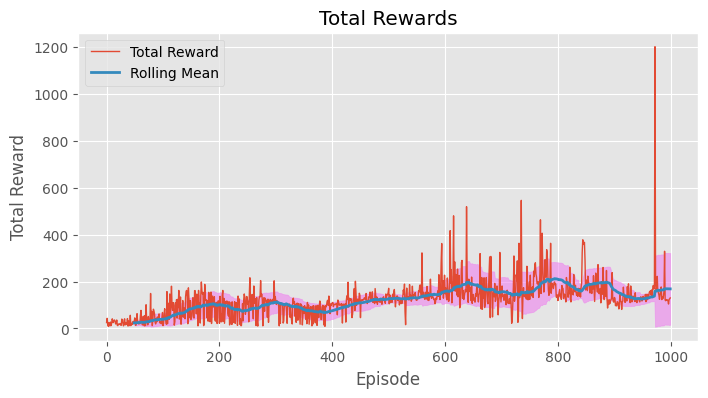

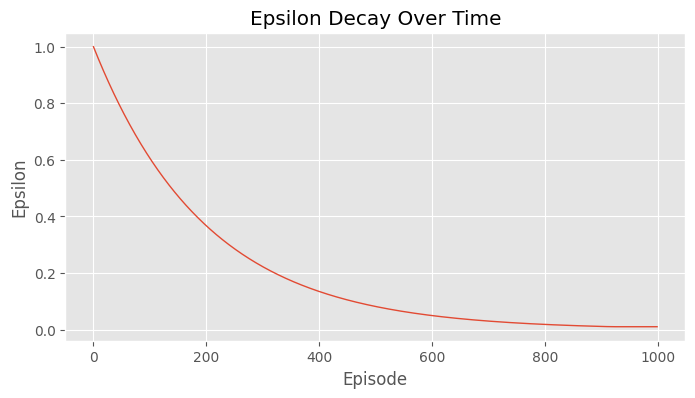

In [ ]:
epsilons = []             # Epsilon during training for each episode
episode_rewards = []      # Rewards during training for each episode

optimizer = tf.keras.optimizers.Adam(learning_rate)           # Defining the optimizer

# Start of the training loop
for episode in range(episodes):
    state, info = env.reset()
    state = state.reshape([1, -1])
    total_reward = 0
    done = False

    while not done:
        # Epsilon-greedy action selection
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            q_values = Q_net(state)
            action = np.argmax(q_values)

        # Take the action and observe the next state
        next_state, reward, done, truncated, info = env.step(action)
        next_state = next_state.reshape([1, -1])

        # Store the transition
        replay_buffer.append((state, action, reward, next_state, done))

        # Sample a batch and train
        if len(replay_buffer) > batch_size:
            batch = random.sample(replay_buffer, batch_size)
            states, actions, rewards, next_states, dones = zip(*batch)

            # Convert to numpy arrays
            states = np.vstack(states)
            next_states = np.vstack(next_states)
            rewards = np.array(rewards)
            dones = np.array(dones)
            actions = np.array(actions)

            # Compute Q-values and train
            with tf.GradientTape() as tape:
                # Get Q-values for the current states and next states
                q_values = Q_net(states)
                next_q_values = Q_net(next_states)

                # Compute target Q-values 
                max_next_q_values = np.max(next_q_values, axis=1)
                target_q_values = rewards + (gamma * max_next_q_values * (1 - dones))

                # Compute loss
                selected_q_values = tf.reduce_sum(q_values * tf.one_hot(actions, env.action_space.n), axis=1)
                loss = tf.reduce_mean(tf.square(target_q_values - selected_q_values))

            grads = tape.gradient(loss, Q_net.trainable_variables)
            optimizer.apply_gradients(zip(grads, Q_net.trainable_variables))

        # Update the state
        state = next_state
        total_reward += reward

    # Update epsilon
    epsilons.append(epsilon)
    epsilon = max(epsilon_end, epsilon * epsilon_decay) if declayed_epsilon else epsilon_fixed
    episode_rewards.append(total_reward)

    # Plot
    plot_score_epsilon(episode_rewards, epsilons)
